# Notebook说明
这是一个消融实验，用于探究CerebriScan_former模型中卷积MoE模块是否有必要添加。 同时探究卷积MoE模块对系统能力的提升程度。

检测系统配置

In [1]:
import os
print('CPU可用核心数:',os.cpu_count())

CPU可用核心数: 52


In [2]:
#获取GPU可用性
import tensorflow as tf
print('GPU可用性:',tf.test.is_gpu_available())
print("可用GPU数: ", len(tf.config.experimental.list_physical_devices('GPU')))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU可用性: True
可用GPU数:  2


2025-09-15 09:46:58.861877: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-15 09:47:01.604044: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:0 with 30980 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:02.0, compute capability: 7.0
2025-09-15 09:47:01.605198: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:1 with 30980 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:04.0, compute capability: 7.0


读取图像文件地址

In [3]:
#读取文件地址
import pandas as pd
ImageFile=pd.read_csv('/root/StrokeDataset/ImageFiles.csv')
ImageFile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   6650 non-null   int64 
 1   Iamge Path   6650 non-null   object
 2   Iamge Label  6650 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 156.0+ KB


In [4]:
#查看数据标签分布
import matplotlib.pyplot as plt
from collections import Counter
def EveluateLabel(labellist):
    print('样本标签统计:',Counter(labellist))
    hist=plt.figure(dpi=72)
    plt.hist(labellist)
    plt.show()

样本标签统计: Counter({0: 4427, 1: 1130, 2: 1093})


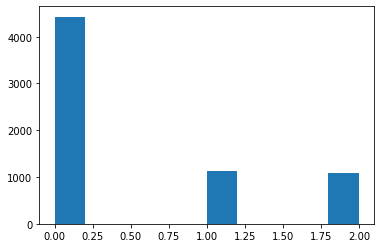

In [5]:
EveluateLabel(labellist=ImageFile.loc[:,'Iamge Label'])

构建数据输入流

In [6]:
#分割数据集+分层抽样
from sklearn.model_selection import train_test_split
TrainPath,SplitPath,TrainLabel,SplitLabel=train_test_split(ImageFile.loc[:,'Iamge Path'],ImageFile.loc[:,'Iamge Label'],train_size=0.7,
                                                           stratify=ImageFile.loc[:,'Iamge Label'],random_state=2025)
ValidPath,TestPath,ValidLabel,TestLabel=train_test_split(SplitPath,SplitLabel,train_size=0.5,stratify=SplitLabel,random_state=2025)
print('训练集地址:{0},验证集地址:{1},测试集地址:{2}'.format(len(TrainPath),len(ValidPath),len(TestPath)))
print('训练集标签:{0},验证集标签:{1},测试集标签:{2}'.format(len(TrainLabel),len(ValidLabel),len(TestLabel)))

训练集地址:4655,验证集地址:997,测试集地址:998
训练集标签:4655,验证集标签:997,测试集标签:998


样本标签统计: Counter({0: 3099, 1: 791, 2: 765})


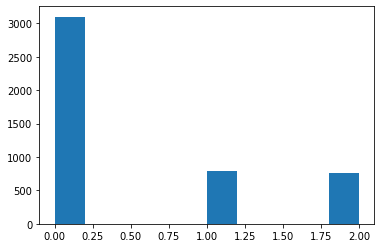

In [7]:
#训练集标签分布
EveluateLabel(labellist=TrainLabel)

样本标签统计: Counter({0: 664, 1: 169, 2: 164})


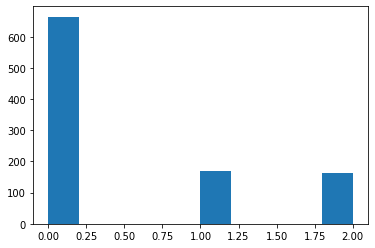

In [8]:
#验证集标签分布
EveluateLabel(labellist=ValidLabel)

样本标签统计: Counter({0: 664, 1: 170, 2: 164})


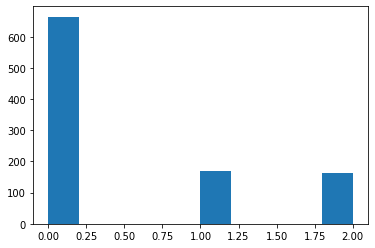

In [9]:
#测试集标签分布
EveluateLabel(labellist=TestLabel)

In [10]:
#编写数据读取函数
import tensorflow as tf
def ReadImageData(path,ImageLabel):
        image_io=tf.io.read_file(path)    #读取文件
        image_data=tf.image.decode_png(image_io,channels=3)    #解码图像数据
        image_datare=tf.image.resize(image_data,(512,512))
        image_normal=tf.cast(image_datare, tf.float32)/255.0
        return (image_normal,ImageLabel)

In [11]:
#使用文件路径方法批量读取数据
#训练集
FilePathDataset_Train=tf.data.Dataset.from_tensor_slices((TrainPath,TrainLabel)).repeat(2)    #文件路径数据集
ImageDataset_Train=FilePathDataset_Train.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Train=ImageDataset_Train.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)
#验证集
FilePathDataset_Valid=tf.data.Dataset.from_tensor_slices((ValidPath,ValidLabel)).repeat(2)    #文件路径数据集
ImageDataset_Valid=FilePathDataset_Valid.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Valid=ImageDataset_Valid.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)
#测试集
FilePathDataset_Test=tf.data.Dataset.from_tensor_slices((TestPath,TestLabel)).repeat(2)    #文件路径数据集
ImageDataset_Test=FilePathDataset_Test.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Test=ImageDataset_Test.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)

2025-09-15 09:47:03.541281: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30980 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:02.0, compute capability: 7.0
2025-09-15 09:47:03.542016: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 30980 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:04.0, compute capability: 7.0


构建卷积MoE模型

In [12]:
#构建卷积神经网络
from tensorflow import keras
#Input shape[512,512,3];Output shape[14,14,64]
def ConvD2DModel(activation):
    EncoderImage=keras.models.Sequential([])
    EncoderImage.add(keras.layers.Input(shape=[512,512,3]))
    #Conv2D Blocks1
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks2 
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks3 
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks4
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(2,2),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2),padding='valid',data_format='channels_last',name='Output_Encoder'))
    return EncoderImage

In [13]:
#定义卷积路由器
class ConvidRounter(keras.layers.Layer):
    def __init__(self,ImageShape,**kwargs):
        super().__init__(**kwargs)
        #卷积Router参数
        self.ImageShape=ImageShape    #输入图像大小
        #定义卷积Router模块
        self.InputLayer = keras.layers.InputLayer(input_shape=self.ImageShape)
        self.Conv2DInput=keras.layers.Conv2D(filters=20,kernel_size=(3,3),strides=(2,2),activation='relu',padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',
                                             bias_initializer='zeros',input_shape=self.ImageShape)
        self.Conv2D2=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D3=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.MaxPooling=keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', data_format='channels_last')
        self.Conv2D4=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D5=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Flatten=keras.layers.Flatten()
        self.Dense=keras.layers.Dense(units=128, activation='relu',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
        self.Problity=keras.layers.Dense(units=4,activation='softmax',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
    def call(self,inputs):
        Input=self.InputLayer(inputs)
        Conv2DOut1=self.Conv2DInput(Input)    #卷积模块
        Conv2DOut2=self.Conv2D2(Conv2DOut1)
        Conv2DOut3=self.Conv2D3(Conv2DOut2)
        MaxPool1=self.MaxPooling(Conv2DOut3)
        Conv2DOut4=self.Conv2D4(MaxPool1)
        Conv2DOut5=self.Conv2D5(Conv2DOut4)
        MaxPool2=self.MaxPooling(Conv2DOut5)    #Outshape[3,5,20]
        FlattenOut=self.Flatten(MaxPool2)
        DenseOut1=self.Dense(FlattenOut)
        ProbilityOut1=self.Problity(DenseOut1)    #Outshape[batch,4]
        return ProbilityOut1
    def compute_output_shape(self):
        return tf.TensorShape([-1,4])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'ImageShape':self.ImageShape}

In [14]:
#基于MoE架构构建卷积MoE层
import tensorflow
from tensorflow import keras
class ConvidMoELayer(keras.layers.Layer):
    #input shape[batch,512,512,3]--> output shape[batch,56,896]
    def __init__(self,Runter,Expoer1,Expoer2,Expoer3,Expoer4,**kwargs):
        super().__init__(**kwargs)
        self.Runter=Runter    #定义路由器模型
        #专家模型
        self.ConvidExpert1=Expoer1
        self.ConvidExpert2=Expoer2
        self.ConvidExpert3=Expoer3
        self.ConvidExpert4=Expoer4
    def call(self,inputs):
        #路由器模型输出概率
        RouterProblityOut=self.Runter(inputs)
        #计算专家模型输出 输入数据[512, 512,3]
        #Expert1
        Expert1Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert2
        Expert2Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert3
        Expert3Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert4
        Expert4Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #整合专家模型输出结果
        ExpertOut=[Expert1Out,Expert2Out,Expert3Out,Expert4Out]    #输出[batch_size, 14, 14，64]
        # 将路由器输出的概率值扩展为与专家输出相同的维度
        router_output_expanded=tf.expand_dims(RouterProblityOut, axis=1)  # [batch_size, 1, 4]
        router_output_expanded=tf.expand_dims(router_output_expanded, axis=1)  # [batch_size, 1, 1, 4]
        router_output_expanded=tf.tile(router_output_expanded, [1, 14, 14, 1])  # [batch_size, 14, 14, 4]
        #将专家输出与路由器概率相乘
        weighted_expert_outputs=[expert_output * router_output_expanded[:, :, :, i:i+1] for i, expert_output in enumerate(ExpertOut)]
        # 展开通道维度并拼接
        reshaped_outputs = [tf.reshape(output, [-1, 14, 896]) for output in weighted_expert_outputs]  # 形状为[batch_size, 14,896]
        MoEOut= tf.concat(reshaped_outputs, axis=1)  # 形状为[batch_size,56,896]
        return MoEOut
    def compute_output_shape(self):
        return tf.TensorShape([56,896])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'Runter':self.Runter,'Expoer1':self.ConvidExpert1,'Expoer2':self.ConvidExpert2,'Expoer3':self.ConvidExpert3,
                'Expoer4':self.ConvidExpert4}

In [15]:
#定义分类模块
def ClassModuleBluid():
    ClassModule=keras.models.Sequential([])
    ClassModule.add(keras.layers.Dense(units=300,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=50,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    return ClassModule

In [16]:
#模型组网
def CerebriScanFormer():
    InputLayer=keras.layers.Input(shape=(512,512, 3),name='InputLayer')    #[batch,512,512,3]
    MoEConv2D=ConvidMoELayer(Runter=Conv2DRouter,Expoer1=ConvD2D_Relu,Expoer2=ConvD2D_Tanh,
                             Expoer3=ConvD2D_ELU,Expoer4=ConvD2D_SELU)(InputLayer)    #[batch,512,512,3]--->[batch,56,896]
    Flatten=keras.layers.Flatten()(MoEConv2D)   #[batch,28,90]--->[batch,2520]
    ClassModule=ClassModuleBluid()(Flatten)
    OutputLayer=keras.layers.Dense(units=3,activation='softmax',name='OutputLayer')(ClassModule)
    CerebriScan_MoE=keras.models.Model(inputs=[InputLayer],outputs=[OutputLayer])
    return CerebriScan_MoE

In [17]:
#配置分布式训练环境
strategy=tf.distribute.MirroredStrategy()
with strategy.scope():
    #卷积专家层
    ConvD2D_Relu=ConvD2DModel(activation='relu')
    ConvD2D_Tanh=ConvD2DModel(activation='tanh')
    ConvD2D_ELU=ConvD2DModel(activation='elu')
    ConvD2D_SELU=ConvD2DModel(activation='selu')
    #定义卷积路由器
    Conv2DRouter=ConvidRounter(ImageShape=(512,512,3))
    CerebriScan_MoE=CerebriScanFormer()    #模型实例化
    #配置编译选项
    Loss=keras.losses.SparseCategoricalCrossentropy()
    Optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
    Metrics=['accuracy']
    LRSchudue=keras.callbacks.ReduceLROnPlateau(patience=10,factor=0.5)   #学习率调度
    CheckPoint=keras.callbacks.ModelCheckpoint('CerebriScan_Former',monitor='val_accuracy',mode='max',save_best_only=True,save_weights_only=False)
    EarlyStoping=keras.callbacks.EarlyStopping(patience=50,monitor='val_accuracy',restore_best_weights=True)
    CerebriScan_MoE.compile(loss=Loss,optimizer=Optimizer,metrics=Metrics)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensor

In [18]:
CerebriScan_MoE.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 InputLayer (InputLayer)     [(None, 512, 512, 3)]     0         
                                                                 
 convid_mo_e_layer (ConvidMo  (None, 56, 896)          361508    
 ELayer)                                                         
                                                                 
 flatten_1 (Flatten)         (None, 50176)             0         
                                                                 
 sequential_4 (Sequential)   (None, 50)                15069550  
                                                                 
 OutputLayer (Dense)         (None, 3)                 153       
                                                                 
Total params: 15,431,211
Trainable params: 15,430,511
Non-trainable params: 700
_______________________________________________

In [19]:
#添加TensorBroad
import os,time
root_logdir=os.path.join('/root/tf-logs','CerebriScan_MoE_logs')
def Get_run_logdir():
    run_id=time.strftime('run_%Y_%m_%d-%H_%M_%S')
    return os.path.join(root_logdir,run_id)
Run_LogsID=Get_run_logdir()
Tensorbroad_CallBacks=keras.callbacks.TensorBoard(Run_LogsID, histogram_freq=1)

In [ ]:
#编译并训练模型
TrainEpoch=100
Label_weights= {0: 5, 1:2.0,2:2.0}    #设置不同类别数据权重
CerebriScanMoE_History=CerebriScan_MoE.fit(ImageDataset_Train,epochs=TrainEpoch,validation_data=(ImageDataset_Valid),
                            callbacks=[LRSchudue,CheckPoint,EarlyStoping,Tensorbroad_CallBacks],class_weight=Label_weights)

187/187 [==============================] - ETA: 0s - loss: 1.9978 - accuracy: 0.7129

2025-09-15 09:48:31.306016: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 997
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:6"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        t

INFO:tensorflow:Assets written to: CerebriScan_Former/assets


INFO:tensorflow:Assets written to: CerebriScan_Former/assets


187/187 [==============================] - 106s 421ms/step - loss: 1.9978 - accuracy: 0.7129 - val_loss: 1.0727 - val_accuracy: 0.3200 - lr: 0.0010
Epoch 2/100
160/187 [========================>.....] - ETA: 8s - loss: 1.0640 - accuracy: 0.8342

In [44]:
#保存模型
CerebriScan_MoE.save('/root/autodl-tmp/StrokeCT_Models/CerebriScan_MoE.h5')
CerebriScan_MoE.save('/root/autodl-tmp/StrokeCT_Models/CerebriScan_MoE')

INFO:tensorflow:Assets written to: /root/autodl-tmp/StrokeCT_Models/CerebriScan_MoE/assets


INFO:tensorflow:Assets written to: /root/autodl-tmp/StrokeCT_Models/CerebriScan_MoE/assets


显示训练结果

In [45]:
from pandas import DataFrame
History=DataFrame(CerebriScanMoE_History.history)
Epoch=History.shape[0]

In [46]:
History.to_csv('/root/NoteBooks/Train_History/CerebriScan_MoE.csv')

In [47]:
#绘制训练曲线
import matplotlib.pyplot as plt
from pandas import DataFrame
import numpy as np
def DisplayCurve(history,epoch):
    fig=plt.figure(figsize=(14,21)) 
    ax1=fig.add_subplot(311) #绘制误差曲线 
    ax1.set_title('loss Curve') 
    #ax1.grid(color='black',linestyle='-.',alpha=0.3) 
    ax1.plot(np.arange(1,Epoch+1),history['loss'],
             color='red',linestyle='-',label='Train loss=%f'%history.loc[:,'loss'].min()) 
    ax1.plot(np.arange(1,Epoch+1),history['val_loss'],
             color='blue',linestyle='-',label='Valid loss=%f'%history.loc[:,'val_loss'].min()) 
    ax1.set_xlabel('Train epochs') 
    ax1.set_ylabel('loss') 
    ax1.legend() 
    fig2=plt.figure(figsize=(14,21)) 
    ax2=fig2.add_subplot(312) #绘制精度曲线 
    ax2.set_title('Classifier Evaluate Curve') 
    #ax2.grid(color='black',linestyle='-.',alpha=0.3) 
    ax2.plot(np.arange(1,Epoch+1),history.iloc[:,1],
             color='red',linestyle='-',label='Train Acccuracy=%f'%history.iloc[:,1].max()) 
    ax2.plot(np.arange(1,Epoch+1),history.iloc[:,3],
             color='blue',linestyle='-',label='Valid Accuracy=%f'%history.iloc[:,3].max()) 
    ax2.set_xlabel('Train epochs') 
    ax2.set_ylabel('Accuracy') 
    ax2.legend()
    fig3=plt.figure(figsize=(14,21)) 
    ax3=fig3.add_subplot(313) #绘制精度曲线 
    ax3.set_title('Learning rate Curve') 
    #ax3.grid(color='black',linestyle='-.',alpha=0.3) 
    ax3.plot(np.arange(1,Epoch+1),history['lr'],color='green',linestyle='-') 
    ax3.set_xlabel('Train epochs') 
    ax3.set_ylabel('Learning rate') 
    ax3.legend()

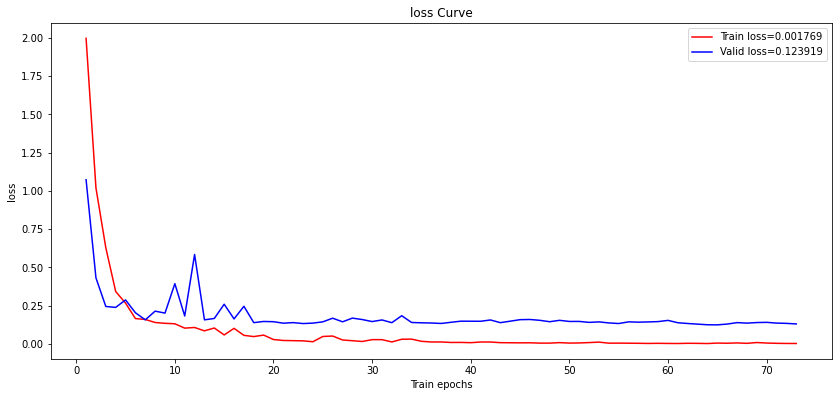

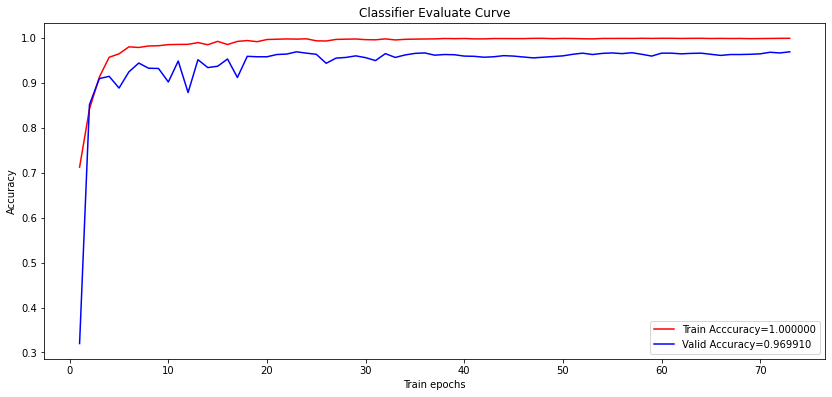

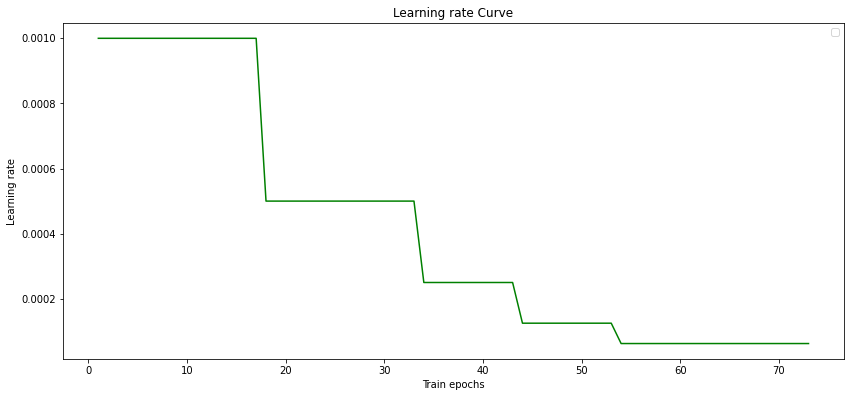

In [48]:
DisplayCurve(history=History,epoch=Epoch)

In [49]:
#计算训练集Accuracy
CerebriScan_MoE.evaluate(ImageDataset_Train,return_dict=True)

2025-09-15 12:10:50.508221: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 4655
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:0"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        

187/187 [==============================] - 32s 163ms/step - loss: 1.4345e-04 - accuracy: 1.0000


{'loss': 0.00014344655210152268, 'accuracy': 1.0}

In [50]:
#评估验证集Accuracy
CerebriScan_MoE.evaluate(ImageDataset_Valid,return_dict=True)

2025-09-15 12:11:25.359397: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 997
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:6"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        t

40/40 [==============================] - 7s 154ms/step - loss: 0.1326 - accuracy: 0.9699


{'loss': 0.13257305324077606, 'accuracy': 0.9699097275733948}

In [51]:
#计算测试集Accuracy
CerebriScan_MoE.evaluate(ImageDataset_Test,return_dict=True)

2025-09-15 12:11:34.106159: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 998
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\025TensorSliceDataset:12"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        

40/40 [==============================] - 7s 153ms/step - loss: 0.2230 - accuracy: 0.9529


{'loss': 0.22296053171157837, 'accuracy': 0.9529058337211609}

评估precision,recall,f1_score,accuracy和混淆举证

In [52]:
def PredictComputeGPU(Model, Dataset):
    # 存储所有批次结果的列表（使用tf.Tensor避免Python对象内存膨胀）
    true_labels = []
    pred_labels = []
    # 遍历数据集批次（已通过batch处理，避免单样本操作）
    for data_batch, label_batch in Dataset:
        # 关键优化：使用模型直接调用替代predict，避免额外内存开销
        # training=False确保推理模式（关闭dropout等）
        with tf.device('/GPU:0'):  # 显式指定GPU加速（如无GPU可移除）
            predict_proba = Model(data_batch, training=False) 
        # 直接在TensorFlow图中计算预测标签（避免numpy转换开销）
        # 等价于原代码的np.argmax + index_proba映射（因index_proba是[0,1,2]可简化）
        predict_label_batch = tf.argmax(predict_proba, axis=1, output_type=tf.int32)  
        # 转换为numpy并存储（批量操作而非单样本）
        true_labels.append(label_batch.numpy())
        pred_labels.append(predict_label_batch.numpy())
    # 合并所有批次结果（一次性操作比逐个append更高效）
    Label = np.concatenate(true_labels, axis=0)
    PredictLabel = np.concatenate(pred_labels, axis=0)
    
    return Label, PredictLabel

In [53]:
#使用评估函数评估模型性能
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score
def ValidClass(Label,PredictLabel):
    TestPrecision=precision_score(Label,PredictLabel,average='micro')
    TestRecall=recall_score(Label,PredictLabel,average='micro')
    TestF1=f1_score(Label,PredictLabel,average='micro')
    TestAccuracy=accuracy_score(Label,PredictLabel)
    print('模型测试集Precision:{0},Recall:{1},F1_score:{2},Accuracy:{3}'.format(TestPrecision,TestRecall,TestF1,TestAccuracy))
    print('-------------------数据集混淆举证-------------------')
    ConfusionMatrix_result=confusion_matrix(Label,PredictLabel,labels=[0,1,2])    #计算混淆举证
    Display_ConfusionMatrix=ConfusionMatrixDisplay(ConfusionMatrix_result,display_labels=['Normal','Ischemia','Bleeding'])
    Display_ConfusionMatrix.plot(include_values=True, cmap='viridis', xticks_rotation='horizontal', values_format='d', ax=None)
    plt.title('Confusion Matrix')
    plt.show()

In [54]:
from sklearn.metrics import classification_report
from scipy.stats import chi2_contingency
from pandas import DataFrame
def Chi2_Test(Label,PredictLabel):
    print('-------------------数据集分类报告-------------------')
    print(classification_report(Label,PredictLabel,target_names=['Normal','Ischemia','Bleeding']))
    contingency_table = pd.crosstab(Label,PredictLabel, rownames=['True Label'], colnames=['Predict Label'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print('-------------------预测标签与真实标签卡方检验结果-------------------')
    print('卡方值为:{0},p值为:{1},自由度为:{2}'.format(chi2,p_value,dof))
    print('-------------------列联表-------------------')
    return DataFrame(contingency_table)

训练集评估

In [55]:
TrainLabel,TrainPredict=PredictComputeGPU(Model=CerebriScan_MoE,Dataset=ImageDataset_Train)

模型测试集Precision:1.0,Recall:1.0,F1_score:1.0,Accuracy:1.0
-------------------数据集混淆举证-------------------


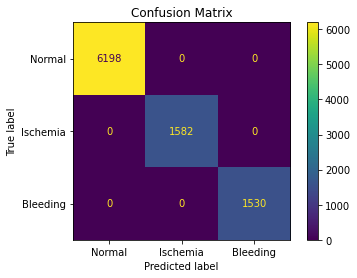

In [56]:
ValidClass(Label=TrainLabel,PredictLabel=TrainPredict)

In [57]:
Train_PE=Chi2_Test(Label=TrainLabel,PredictLabel=TrainPredict)

-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6198
    Ischemia       1.00      1.00      1.00      1582
    Bleeding       1.00      1.00      1.00      1530

    accuracy                           1.00      9310
   macro avg       1.00      1.00      1.00      9310
weighted avg       1.00      1.00      1.00      9310

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:18620.0,p值为:0.0,自由度为:4
-------------------列联表-------------------


In [ ]:
Train_PE

验证集评估

In [58]:
ValidLabel,ValidPredict=PredictComputeGPU(Model=CerebriScan_MoE,Dataset=ImageDataset_Valid)

模型测试集Precision:0.9699097291875627,Recall:0.9699097291875627,F1_score:0.9699097291875627,Accuracy:0.9699097291875627
-------------------数据集混淆举证-------------------


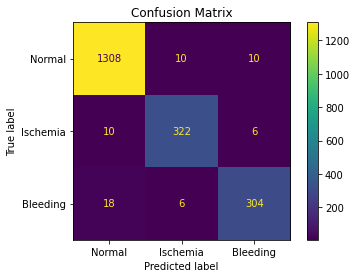

In [59]:
ValidClass(Label=ValidLabel,PredictLabel=ValidPredict)

In [60]:
Valid_PE=Chi2_Test(Label=ValidLabel,PredictLabel=ValidPredict)

-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      1328
    Ischemia       0.95      0.95      0.95       338
    Bleeding       0.95      0.93      0.94       328

    accuracy                           0.97      1994
   macro avg       0.96      0.95      0.96      1994
weighted avg       0.97      0.97      0.97      1994

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:3498.329161558197,p值为:0.0,自由度为:4
-------------------列联表-------------------


In [ ]:
Valid_PE

测试集评估

In [61]:
TestLabel,TestPredict=PredictComputeGPU(Model=CerebriScan_MoE,Dataset=ImageDataset_Test)

模型测试集Precision:0.9529058116232465,Recall:0.9529058116232465,F1_score:0.9529058116232465,Accuracy:0.9529058116232465
-------------------数据集混淆举证-------------------


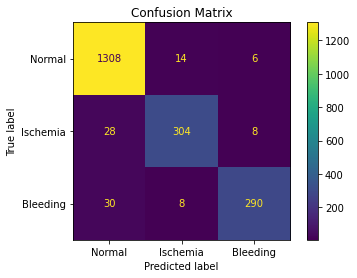

In [62]:
ValidClass(Label=TestLabel,PredictLabel=TestPredict)

In [63]:
Test_PE=Chi2_Test(Label=TestLabel,PredictLabel=TestPredict)

-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97      1328
    Ischemia       0.93      0.89      0.91       340
    Bleeding       0.95      0.88      0.92       328

    accuracy                           0.95      1996
   macro avg       0.95      0.92      0.93      1996
weighted avg       0.95      0.95      0.95      1996

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:3245.0636097033257,p值为:0.0,自由度为:4
-------------------列联表-------------------


In [64]:
Test_PE

Predict Label,0,1,2
True Label,,,
0,1308,14,6
1,28,304,8
2,30,8,290
